In [ ]:
# TODO
# - Directly import .bbl files using orangebox library
# - Figure out issue with yaw axis data collection (I think it needs a chirp sweep at a lower frequency?)

In [1]:
from plant_fit import *

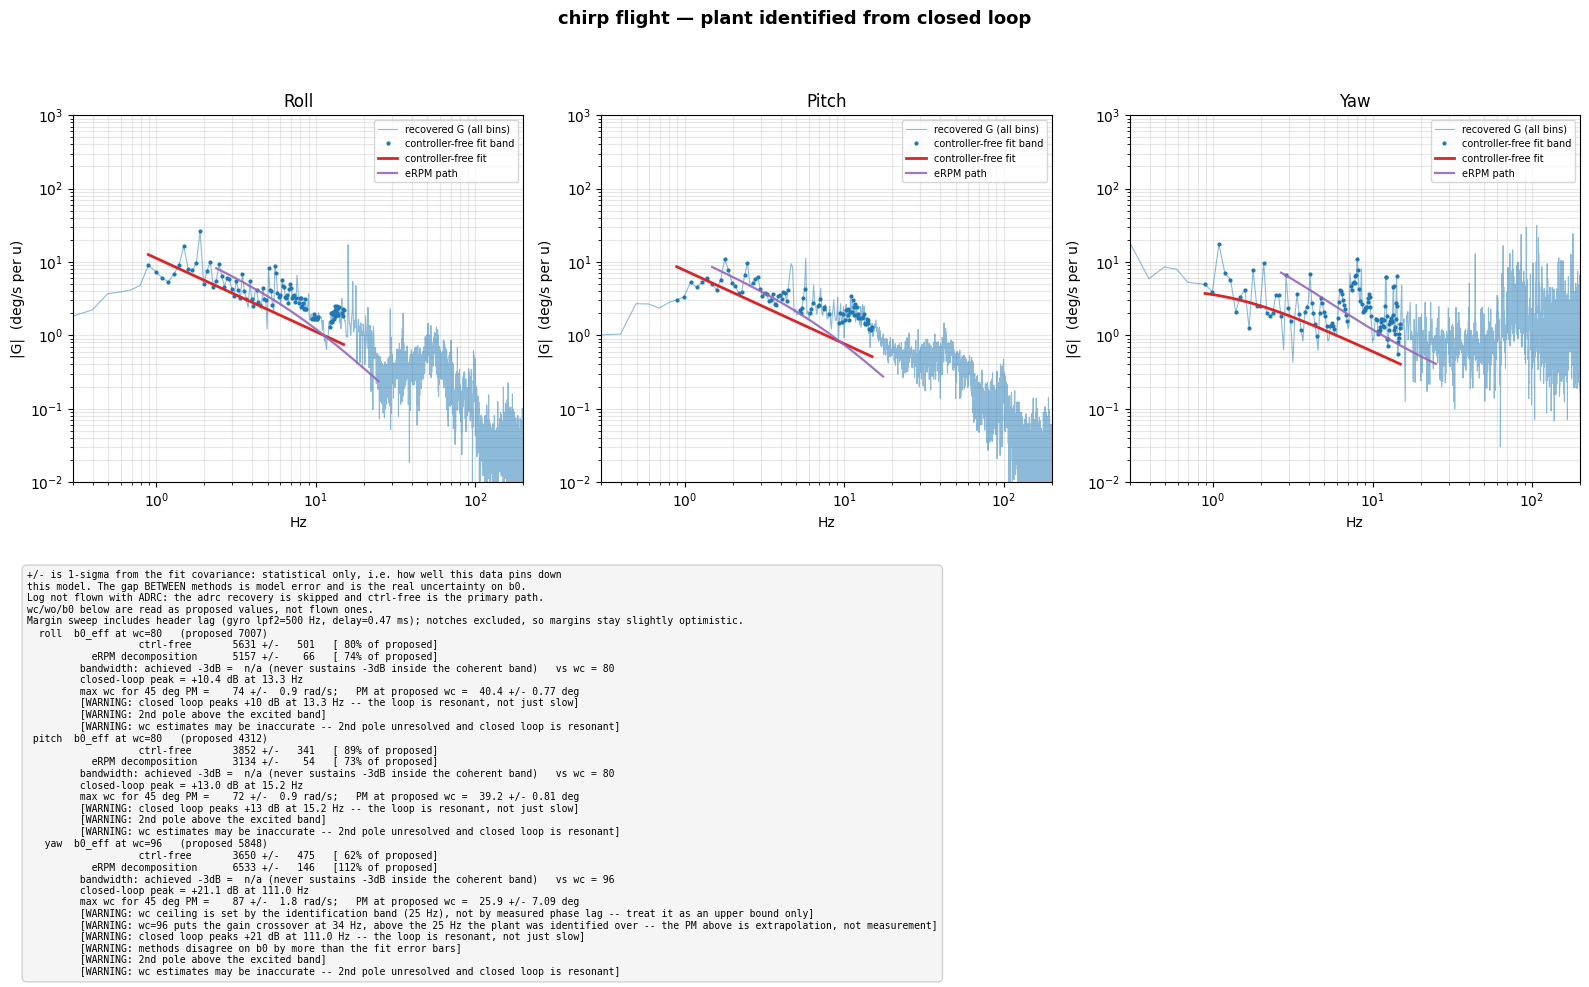

Saved plot to Output metrics\chirp flight Plant fit.png
Saved metrics log to Output metrics\chirp flight Plant fit.txt


axis,ctrl-free,eRPM,gap
roll,5631 +/- 501,5157 +/- 66,9%
pitch,3852 +/- 341,3134 +/- 54,21%
yaw,3650 +/- 475,6533 +/- 146,57%


axis,achieved -3dB,max wc @45 deg,max wc @60 deg,PM at proposed wc
roll,n/a,74 +/- 0.9 rad/s,57 +/- 0.8 rad/s,40.4 +/- 0.77 deg
pitch,n/a,72 +/- 0.9 rad/s,55 +/- 0.8 rad/s,39.2 +/- 0.81 deg
yaw,n/a,87 +/- 1.8 rad/s,82 +/- 1.7 rad/s,25.9 +/- 7.09 deg



[WARNING:  roll] closed loop peaks +10 dB at 13.3 Hz -- the loop is resonant, not just slow
[WARNING:  roll] 2nd pole above the excited band
[WARNING:  roll] wc estimates may be inaccurate -- 2nd pole unresolved and closed loop is resonant
[WARNING: pitch] closed loop peaks +13 dB at 15.2 Hz -- the loop is resonant, not just slow
[WARNING: pitch] 2nd pole above the excited band
[WARNING: pitch] wc estimates may be inaccurate -- 2nd pole unresolved and closed loop is resonant
[WARNING:   yaw] wc ceiling is set by the identification band (25 Hz), not by measured phase lag -- treat it as an upper bound only
[WARNING:   yaw] wc=96 puts the gain crossover at 34 Hz, above the 25 Hz the plant was identified over -- the PM above is extrapolation, not measurement
[WARNING:   yaw] closed loop peaks +21 dB at 111.0 Hz -- the loop is resonant, not just slow
[WARNING:   yaw] methods disagree on b0 by more than the fit error bars
[WARNING:   yaw] 2nd pole above the excited band
[WARNING:   yaw] wc 

In [2]:
# Path to betaflight log, should be exported as CSV
csv_path = 'chirp flight.csv'

# Was this log flown with ADRC?
#   True  - flown with the wc/wo/b0 below. 
#   False - flown with PID (or anything else).
adrc_flight = False
# ADRC parameters flown with (ignored if adrc_flight = False)
wc = {"roll": 80,  "pitch": 80,  "yaw": 96}
wo = {"roll": 103, "pitch": 103, "yaw": 125}
b0 = {"roll": 7007, "pitch": 4312, "yaw": 5848}

# Fit plots of transfer functions, inspect these to make sure they look somewhat reasonable
# If these are nonsensical looking all of the output will be nonsensical

# b0 table with values from each of the fit methods, use your own judgement if these disagree significantly

# From bandwidth table achieved -3dB basically tells the fastest response the system actually keeps up with
# vs wc column has a ratio basically says how fast the controller is responding, this should be around 2x. 
# If this ratio is large (over ~5x) that means something is off, likely b0

# Start tuning with recovered b0 values for each axis for fit that most closely matches recovered G
# This will likely be the controller-free fit band if using a chirp flight

# Yaw plant recovery and subsequent fits are somewhat inconsistent, this seems to be an actual issue with the data
# If a warning appears for the yaw axis saying something extrapolated values, start tuning using wc/wo around
# roll and pitch axis values. 

# Results are all output into a folder named 'Output Metrics'

results, b0_table, bw_table = show_fit_summary(csv_path, wc, wo, b0, f_hi = 15, coh_min = 0.3, adrc_flight = adrc_flight)